In [19]:
# ============================================================
# 0) Setup + Data Loading & Cleaning
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path(r"C:\Users\kagan_ntaijui\VertigoCaseStudy\Task2\Data")
DATE_COLS = ["event_date", "install_date"]

REQUIRED_COLS = [
    "user_id", "event_date", "platform", "install_date", "country",
    "total_session_count", "total_session_duration",
    "match_start_count", "match_end_count",
    "victory_count", "defeat_count",
    "server_connection_error", "iap_revenue", "ad_revenue"
]

def load_game_csvs(data_dir: Path) -> pd.DataFrame:
    if not data_dir.exists():
        raise FileNotFoundError(f"Data directory not found: {data_dir}")

    files = sorted(data_dir.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found in: {data_dir}")

    frames = []
    for fp in files:
        df = pd.read_csv(fp, low_memory=False)
        df["source_file"] = fp.name
        frames.append(df)

    out = pd.concat(frames, ignore_index=True)
    return out

def profile_df(df: pd.DataFrame, head_n: int = 3) -> None:
    print("=== Dataset Loaded ===")
    print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
    mem_mb = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memory: {mem_mb:,.1f} MB")

    if "event_date" in df.columns:
        print(f"Event date range: {df['event_date'].min()}  ->  {df['event_date'].max()}")

    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    miss = miss[miss > 0].head(10)
    if len(miss) > 0:
        print("\nTop missing columns (%):")
        for k, v in miss.items():
            print(f"  - {k}: {v:.2f}%")
    else:
        print("\nNo missing values detected.")

    print("\nColumns:")
    print(df.columns.tolist())

    print(f"\nPreview (first {head_n} rows):")
    display(df.head(head_n))

# ----------------------------
# Load
# ----------------------------
game_data = load_game_csvs(DATA_DIR)

# ----------------------------
# Basic cleaning
# ----------------------------

# Schema validation to ensure all csv files have required columns
missing_cols = [c for c in REQUIRED_COLS if c not in game_data.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Parse dates
for c in DATE_COLS:
    game_data[c] = pd.to_datetime(game_data[c], errors="coerce")

# Revenue NaNs -> 0
for c in ["iap_revenue", "ad_revenue"]:
    game_data[c] = pd.to_numeric(game_data[c], errors="coerce").fillna(0.0)

# Standardize country
game_data["country"] = game_data["country"].astype("string")
game_data["country"] = game_data["country"].str.strip().str.upper()
game_data["country"] = game_data["country"].fillna("UNKNOWN") # Many missing countries, we treat as UNKNOWN

# Basic sanity checks
print("\n=== Sanity Checks ===")
print(f"Unique users: {game_data['user_id'].nunique():,}")
print(f"Platforms: {sorted(game_data['platform'].dropna().unique().tolist())}")
print(f"Unknown country rate: {(game_data['country'].eq('UNKNOWN').mean() * 100):.2f}%")

# ----------------------------
# Profile
# ----------------------------
profile_df(game_data)



=== Sanity Checks ===
Unique users: 2,453,499
Platforms: ['android', 'ios']
Unknown country rate: 0.25%
=== Dataset Loaded ===
Rows: 7,293,526 | Columns: 15
Memory: 2,300.8 MB
Event date range: 2024-02-15 00:00:00  ->  2024-03-15 00:00:00

No missing values detected.

Columns:
['user_id', 'event_date', 'platform', 'install_date', 'country', 'total_session_count', 'total_session_duration', 'match_start_count', 'match_end_count', 'victory_count', 'defeat_count', 'server_connection_error', 'iap_revenue', 'ad_revenue', 'source_file']

Preview (first 3 rows):


,user_id,event_date,platform,install_date,country,total_session_count,total_session_duration,match_start_count,match_end_count,victory_count,defeat_count,server_connection_error,iap_revenue,ad_revenue,source_file
0,C6C0A027C49B98BA,2024-02-16,android,2024-02-11,UNKNOWN,1,57.721,0,0,0,0,0,0.0,0.0,000000000000.csv
1,EE03D492BC0ED08C,2024-03-08,ios,2024-02-01,UNKNOWN,0,0.355,0,0,0,0,0,0.0,0.0,000000000000.csv
2,5CAA4AF817354059,2024-03-12,ios,2024-03-12,UNKNOWN,1,114.006,0,0,0,0,0,0.0,0.0,000000000000.csv


----

## 1) Rage Quit & Match Completion (Volume-Controlled)

### Objective
In an FPS game, early frustration often comes from failing to complete matches (disconnects, crashes, rage-quits, or simply disengagement). This analysis tests whether **Day-0 match completion** is associated with:
- **D7 / D14 retention** (proxy: user has any event on day 7 / 14),
- **30-day monetization** (IAP + Ad revenue),
- Whether **“rage-quit-like” behavior** is linked to connectivity errors.


### Key Definitions

1. **Horizon (30D):**  
   Only events within the first 30 days after install are used for retention and monetization outcomes.

2. **Completion rate (D0):**  
   `match_end_count / match_start_count` aggregated on Day 0.

3. **Volume control:**  
   To avoid labeling players with too little activity, we only interpret completion rate if a user started at least `MIN_MATCHES_FOR_COMPLETION` matches on Day 0. Otherwise, they are bucketed as **Low volume**.

4. **Rage quit proxy (VC):**  
   A user who started `MIN_MATCHES_FOR_COMPLETION` matches on Day 0 and has `completion_rate < RQ_COMPLETION_THRESHOLD`.

5. **Connectivity split:**  
   Rage quit proxy users are split into:
   - **RQ + Connectivity errors:** Users with `server errors > 0` on Day 0.
   - **RQ + No errors:** Users without server errors.


### Outputs

#### Baseline Rates
- **D7/D14 retention**
- **Average 30D revenue**
- **Payer rate**
- **Active days**

#### Summary Tables
1. **Completion buckets →** Retention, revenue, payer rate, and lifts.
2. **Rage quit proxy segments →** Retention, revenue, and lifts.
3. **Completion × Win cross-table (volume-controlled).**

#### Plots
1. **D7 retention by completion bucket.**
2. **30D revenue by completion bucket.**
3. **30D revenue by rage quit segment.**

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1.1) Helpers
# ============================================================

CFG = {
    "HORIZON_DAYS": 30,
    "MIN_MATCHES_FOR_COMPLETION": 3,
    "RQ_COMPLETION_THRESHOLD": 0.70,
    "TOPN_CROSS": 12,
}

def prep_horizon_events(game_data: pd.DataFrame, horizon_days: int) -> pd.DataFrame:
    """Parse dates, compute days_since_install, filter to [0, horizon_days-1]."""
    df = game_data.copy()
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
    df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
    df = df.dropna(subset=["event_date", "install_date"])

    df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")
    dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (horizon_days - 1))].copy()

    # Normalize revenue and compute total revenue
    dfh["iap_revenue"] = pd.to_numeric(dfh["iap_revenue"], errors="coerce").fillna(0.0)
    dfh["ad_revenue"] = pd.to_numeric(dfh["ad_revenue"], errors="coerce").fillna(0.0)
    dfh["total_revenue"] = dfh["iap_revenue"] + dfh["ad_revenue"]

    # Optional memory reduction
    for c in ["platform", "country"]:
        if c in dfh.columns:
            dfh[c] = dfh[c].astype("category")

    return dfh

def build_day0_features(dfh: pd.DataFrame) -> pd.DataFrame:
    """Aggregate D0 gameplay/monetization signals per user."""
    d0 = dfh[dfh["days_since_install"] == 0].copy()

    d0_agg = d0.groupby("user_id", as_index=False).agg(
        platform=("platform", "first"),
        country=("country", "first"),
        total_session_count_d0=("total_session_count", "sum"),
        total_session_duration_d0=("total_session_duration", "sum"),
        match_start_count_d0=("match_start_count", "sum"),
        match_end_count_d0=("match_end_count", "sum"),
        victory_count_d0=("victory_count", "sum"),
        defeat_count_d0=("defeat_count", "sum"),
        server_connection_error_d0=("server_connection_error", "sum"),
        iap_revenue_d0=("iap_revenue", "sum"),
        ad_revenue_d0=("ad_revenue", "sum"),
    )

    # Derived ratios (vectorized)
    starts = d0_agg["match_start_count_d0"].astype("float64")
    ends = d0_agg["match_end_count_d0"].astype("float64")
    d0_agg["completion_rate_d0"] = np.where(starts > 0, ends / starts, np.nan)

    wins = d0_agg["victory_count_d0"].astype("float64")
    losses = d0_agg["defeat_count_d0"].astype("float64")
    den = wins + losses
    d0_agg["win_rate_d0"] = np.where(den > 0, wins / den, np.nan)

    d0_agg["connectivity_flag_d0"] = (d0_agg["server_connection_error_d0"] > 0).astype("int8")
    return d0_agg

def build_outcomes(dfh: pd.DataFrame) -> pd.DataFrame:
    """Retention proxy + horizon monetization outcomes per user."""
    dfh = dfh.copy()
    dfh["is_d7"] = (dfh["days_since_install"] == 7).astype("int8")
    dfh["is_d14"] = (dfh["days_since_install"] == 14).astype("int8")

    out = dfh.groupby("user_id", as_index=False).agg(
        retained_d7=("is_d7", "max"),
        retained_d14=("is_d14", "max"),
        active_days_h=("event_date", "nunique"),
        iap_rev_h=("iap_revenue", "sum"),
        ad_rev_h=("ad_revenue", "sum"),
        revenue_h=("total_revenue", "sum"),
    )
    out["iap_payer_h"] = (out["iap_rev_h"] > 0).astype("int8")
    return out

def add_lifts(df: pd.DataFrame, baseline: dict) -> pd.DataFrame:
    """Attach lift columns (metric / baseline)."""
    out = df.copy()
    out["d7_lift"] = np.where(baseline["d7"] > 0, out["d7_retention"] / baseline["d7"], np.nan)
    out["d14_lift"] = np.where(baseline["d14"] > 0, out["d14_retention"] / baseline["d14"], np.nan)
    out["rev_lift"] = np.where(baseline["rev"] > 0, out["avg_revenue_h"] / baseline["rev"], np.nan)
    out["payer_lift"] = np.where(baseline["payer"] > 0, out["payer_rate_h"] / baseline["payer"], np.nan)
    return out

def pretty_print_df(title: str, df: pd.DataFrame, max_rows: int = 50) -> None:
    print(f"\n{title}")
    print(df.head(max_rows).to_string(index=False))

def plot_bar(df, x, y, title, ylabel, rotate=25, figsize=(10, 4)):
    plt.figure(figsize=figsize)
    plt.bar(df[x].astype(str), df[y].astype(float))
    plt.xticks(rotation=rotate, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [21]:
# ============================================================
# 1.2) Build user-level dataset (D0 features + 30D outcomes) + segments
# ============================================================

H = CFG["HORIZON_DAYS"]
MIN_VOL = CFG["MIN_MATCHES_FOR_COMPLETION"]
RQ_T = CFG["RQ_COMPLETION_THRESHOLD"]

dfh = prep_horizon_events(game_data, horizon_days=H)
d0_feat = build_day0_features(dfh)
outcomes = build_outcomes(dfh)

# Inner join ensures we only analyze users with D0 data + outcomes within horizon
user = d0_feat.merge(outcomes, on="user_id", how="inner")

# --- Segmentation (vectorized) ---
starts = user["match_start_count_d0"].fillna(0)
cr = user["completion_rate_d0"]
wr = user["win_rate_d0"]

# Completion bucket (volume-controlled)
user["completion_bucket_vc"] = np.select(
    [
        starts < MIN_VOL,
        cr.isna(),
        cr < 0.70,
        cr < 0.90,
        cr >= 0.90,
    ],
    [
        f"Low volume (<{MIN_VOL} starts)",
        "Unknown completion",
        "Low completion (<0.70)",
        "Mid completion (0.70–0.90)",
        "High completion (>=0.90)",
    ],
    default="Unknown completion"
)

# Win bucket
user["win_bucket"] = np.select(
    [
        wr.isna(),
        wr < 0.40,
        wr <= 0.60,
        wr > 0.60
    ],
    [
        "No outcome (D0)",
        "Low win (<0.40)",
        "Mid win (0.40–0.60)",
        "High win (>0.60)"
    ],
    default="No outcome (D0)"
)

# Rage quit proxy (volume-controlled)
user["rage_quit_proxy_vc"] = ((starts >= MIN_VOL) & (cr.fillna(1.0) < RQ_T)).astype("int8")

# Connectivity split
user["rq_segment"] = np.select(
    [
        user["rage_quit_proxy_vc"] == 0,
        (user["rage_quit_proxy_vc"] == 1) & (user["connectivity_flag_d0"] == 1),
        (user["rage_quit_proxy_vc"] == 1) & (user["connectivity_flag_d0"] == 0),
    ],
    [
        "Not RQ (baseline)",
        "RQ + Connectivity errors",
        "RQ + No errors",
    ],
    default="Not RQ (baseline)"
)

# Sanity prints
print("=== Build complete ===")
print(f"Users in analysis table: {len(user):,}")
print(user[["completion_bucket_vc", "rq_segment", "win_bucket"]].head(3))


=== Build complete ===
Users in analysis table: 1,056,852
     completion_bucket_vc         rq_segment           win_bucket
0  Low completion (<0.70)     RQ + No errors  Mid win (0.40–0.60)
1  Low completion (<0.70)     RQ + No errors     High win (>0.60)
2  Low volume (<3 starts)  Not RQ (baseline)  Mid win (0.40–0.60)


=== Baselines (within horizon) ===
D7=0.0555 | D14=0.0230 | AvgRev=0.1993 | PayerRate=0.0097 | AvgActiveDays=2.28

=== Completion Buckets (Volume-Controlled) ===
      completion_bucket_vc  users  d7_retention  d14_retention  avg_revenue_h  avg_iap_h  avg_ad_h  payer_rate_h  avg_active_days_h  d7_lift  d14_lift  rev_lift  payer_lift
  High completion (>=0.90) 392514      0.078876       0.034233       0.399611   0.300877  0.098735      0.018715           2.792262 1.421635  1.486234  2.005420    1.928931
Mid completion (0.70–0.90) 116694      0.090930       0.036523       0.241214   0.166644  0.074570      0.013163           3.065213 1.638892  1.585641  1.210513    1.356637
    Low completion (<0.70)  58907      0.050164       0.018894       0.092253   0.067111  0.025141      0.004244           2.181354 0.904134  0.820292  0.462962    0.437415
    Low volume (<3 starts) 488737      0.028872       0.011317       0.041247   0.026941  0.014306      0.002296           1.694378 0.520385  0.49

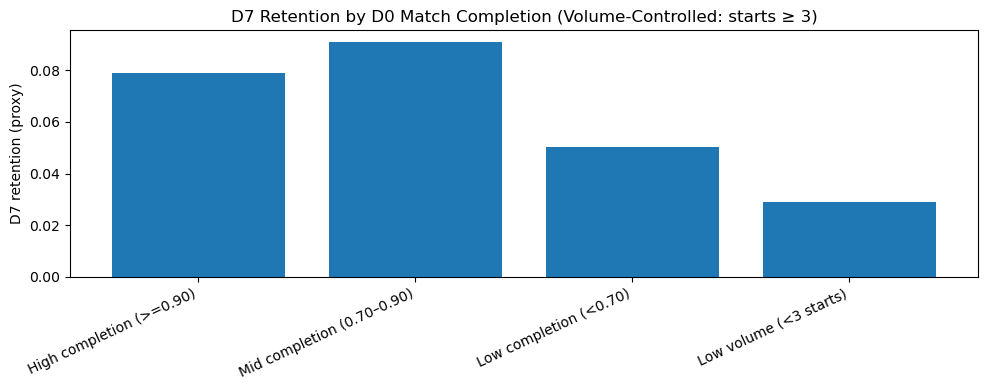

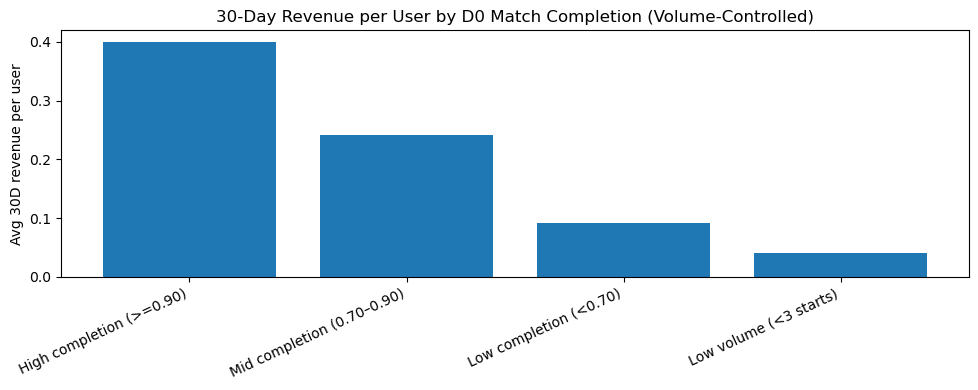

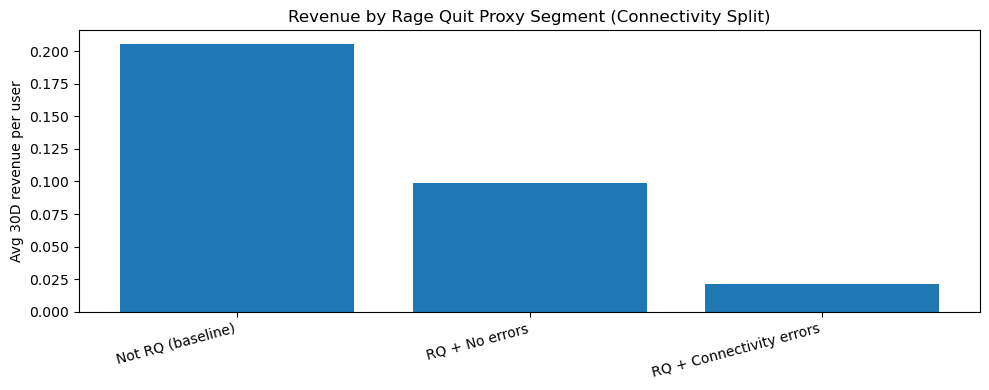

In [22]:
# ============================================================
# 1.3) Reporting Outputs: baselines + summary tables + plots
# ============================================================

TOPN = CFG["TOPN_CROSS"]
H = CFG["HORIZON_DAYS"]
MIN_VOL = CFG["MIN_MATCHES_FOR_COMPLETION"]

# Baselines
baseline = {
    "d7": float(user["retained_d7"].mean()),
    "d14": float(user["retained_d14"].mean()),
    "rev": float(user["revenue_h"].mean()),
    "payer": float(user["iap_payer_h"].mean()),
    "active_days": float(user["active_days_h"].mean()),
}

print("=== Baselines (within horizon) ===")
print(
    f"D7={baseline['d7']:.4f} | D14={baseline['d14']:.4f} | "
    f"AvgRev={baseline['rev']:.4f} | PayerRate={baseline['payer']:.4f} | "
    f"AvgActiveDays={baseline['active_days']:.2f}"
)

# ---- Completion summary ----
bucket_order = [
    "High completion (>=0.90)",
    "Mid completion (0.70–0.90)",
    "Low completion (<0.70)",
    f"Low volume (<{MIN_VOL} starts)",
    "Unknown completion",
]

summary_comp = (
    user.groupby("completion_bucket_vc", observed=True)
        .agg(
            users=("user_id", "nunique"),
            d7_retention=("retained_d7", "mean"),
            d14_retention=("retained_d14", "mean"),
            avg_revenue_h=("revenue_h", "mean"),
            avg_iap_h=("iap_rev_h", "mean"),
            avg_ad_h=("ad_rev_h", "mean"),
            payer_rate_h=("iap_payer_h", "mean"),
            avg_active_days_h=("active_days_h", "mean"),
        )
        .reset_index()
)
summary_comp["order"] = summary_comp["completion_bucket_vc"].apply(lambda x: bucket_order.index(x) if x in bucket_order else 999)
summary_comp = summary_comp.sort_values(["order", "users"], ascending=[True, False]).drop(columns=["order"])
summary_comp = add_lifts(summary_comp, baseline)

pretty_print_df("=== Completion Buckets (Volume-Controlled) ===", summary_comp)

# ---- Rage quit summary ----
rq_order = ["Not RQ (baseline)", "RQ + No errors", "RQ + Connectivity errors"]

summary_rq = (
    user.groupby("rq_segment", observed=True)
        .agg(
            users=("user_id", "nunique"),
            d7_retention=("retained_d7", "mean"),
            d14_retention=("retained_d14", "mean"),
            avg_revenue_h=("revenue_h", "mean"),
            payer_rate_h=("iap_payer_h", "mean"),
            avg_active_days_h=("active_days_h", "mean"),
        )
        .reset_index()
)
summary_rq["order"] = summary_rq["rq_segment"].apply(lambda x: rq_order.index(x) if x in rq_order else 999)
summary_rq = summary_rq.sort_values(["order"]).drop(columns=["order"])
summary_rq = add_lifts(summary_rq, baseline)

pretty_print_df("=== Rage Quit Proxy (Volume-Controlled) + Connectivity Split ===", summary_rq)

# ---- Cross: Completion x Win (Volume Controlled) ----
starts = user["match_start_count_d0"].fillna(0)
user_vc = user[starts >= MIN_VOL].copy()

cross = (
    user_vc.groupby(["completion_bucket_vc", "win_bucket"], observed=True)
        .agg(
            users=("user_id", "nunique"),
            d7_retention=("retained_d7", "mean"),
            avg_revenue_h=("revenue_h", "mean"),
            payer_rate_h=("iap_payer_h", "mean"),
        )
        .reset_index()
        .sort_values("users", ascending=False)
)

pretty_print_df(f"=== Completion × Win (starts ≥ {MIN_VOL}, top {TOPN}) ===", cross, max_rows=TOPN)

# ---- Plots ----
plot_bar(
    summary_comp, "completion_bucket_vc", "d7_retention",
    title=f"D7 Retention by D0 Match Completion (Volume-Controlled: starts ≥ {MIN_VOL})",
    ylabel="D7 retention (proxy)"
)

plot_bar(
    summary_comp, "completion_bucket_vc", "avg_revenue_h",
    title=f"{H}-Day Revenue per User by D0 Match Completion (Volume-Controlled)",
    ylabel=f"Avg {H}D revenue per user"
)

plot_bar(
    summary_rq, "rq_segment", "avg_revenue_h",
    title="Revenue by Rage Quit Proxy Segment (Connectivity Split)",
    ylabel=f"Avg {H}D revenue per user",
    rotate=15
)


----

## 2) Early Value Signal Discovery (Thresholds with Shallow Decision Trees)

### Objective
Identify simple, early behavioral thresholds (e.g., “≥ X minutes played in first day” or “≥ Y matches in first 3 days”) that predict whether a player becomes high-value within 30 days.

This is useful for:
- **Early player segmentation:** Identifying which players to nurture.
- **Understanding early behaviors:** Correlating early behaviors with monetization.
- **Designing product interventions:** Improving tutorials, matchmaking, rewards, and offer timing.


### Target Definition (What is “high-value”?)
We define a **High-Value User** as:
- The **top 10% of users** by total 30-day revenue (IAP + Ad) within a 30-day post-install horizon.


### Feature Windows (Early Signals)
We compare:
1. **D0:** Signals from the install day only.
2. **D0–D2:** Signals from the first 3 days.


### Modeling Approach (Interpretability-first)
We use **shallow decision trees** (max depth 3) because they produce human-readable rules.

#### Example Rule:
`total_session_duration_d0_d2 > 1800 seconds AND match_start_count_d0_d2 >= 8`

#### Evaluation Metrics:
1. **AUC and PR-AUC:** To measure ranking quality.
2. **Business framing:** Top-10% scored segment lift (how concentrated high-value users are in the predicted top segment).
3. **Top leaf rules:** Identifying the highest high-value rate with meaningful support.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support

# ============================================================
# 2.1) Helpers
# ============================================================

CFG2 = {
    "HORIZON_DAYS": 30,
    "FEATURE_WINDOWS": {
        "D0": (0, 0),
        "D0_D2": (0, 2),
    },
    "TOP_VALUE_PERCENTILE": 0.90,     # top 10%
    "TEST_SIZE": 0.20,
    "RANDOM_STATE": 42,
    "TREE_MAX_DEPTH": 3,
    "MIN_SAMPLES_LEAF": 2000,
    "MIN_USERS_PER_COUNTRY": 5000,
}

def prep_horizon_events_for_value(game_data: pd.DataFrame, horizon_days: int) -> pd.DataFrame:
    """Prepare event table for value modeling: parse dates, days_since_install, horizon filter, revenue columns."""
    df = game_data.copy()
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
    df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
    df = df.dropna(subset=["event_date", "install_date"])

    df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")
    dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (horizon_days - 1))].copy()

    dfh["iap_revenue"] = pd.to_numeric(dfh["iap_revenue"], errors="coerce").fillna(0.0)
    dfh["ad_revenue"] = pd.to_numeric(dfh["ad_revenue"], errors="coerce").fillna(0.0)
    dfh["total_revenue"] = dfh["iap_revenue"] + dfh["ad_revenue"]

    for c in ["platform", "country"]:
        if c in dfh.columns:
            dfh[c] = dfh[c].astype("category")

    return dfh


def build_user_outcomes_30d(dfh: pd.DataFrame) -> pd.DataFrame:
    """Compute 30D revenue outcomes per user (target)."""
    out = dfh.groupby("user_id", as_index=False).agg(
        revenue_30d=("total_revenue", "sum"),
        iap_rev_30d=("iap_revenue", "sum"),
        ad_rev_30d=("ad_revenue", "sum"),
        install_date=("install_date", "first"),
        platform=("platform", "first"),
        country=("country", "first"),
    )
    return out


def tier_countries_by_avg_revenue(user_df: pd.DataFrame, min_users: int) -> dict:
    """
    Self-contained country tiering using this dataset only:
    eligible countries (>= min_users) are split into terciles by avg revenue_30d.
    """
    cs = user_df.groupby("country", as_index=False).agg(
        users=("user_id", "nunique"),
        avg_rev=("revenue_30d", "mean"),
    )
    eligible = cs[cs["users"] >= min_users].copy()
    if eligible.empty:
        return {}

    q1, q2 = eligible["avg_rev"].quantile([0.33, 0.66]).values

    def tier(x):
        if x <= q1:
            return "Tier3_low"
        if x <= q2:
            return "Tier2_mid"
        return "Tier1_high"

    eligible["country_tier"] = eligible["avg_rev"].apply(tier)
    return dict(zip(eligible["country"], eligible["country_tier"]))


def aggregate_user_features_window(dfh: pd.DataFrame, day_min: int, day_max: int, suffix: str) -> pd.DataFrame:
    """Aggregate early user features over [day_min, day_max] since install."""
    w = dfh[dfh["days_since_install"].between(day_min, day_max)].copy()

    feats = w.groupby("user_id", as_index=False).agg(
        platform=("platform", "first"),
        country=("country", "first"),

        **{
            f"total_session_count_{suffix}": ("total_session_count", "sum"),
            f"total_session_duration_{suffix}": ("total_session_duration", "sum"),
            f"match_start_count_{suffix}": ("match_start_count", "sum"),
            f"match_end_count_{suffix}": ("match_end_count", "sum"),
            f"victory_count_{suffix}": ("victory_count", "sum"),
            f"defeat_count_{suffix}": ("defeat_count", "sum"),
            f"server_connection_error_{suffix}": ("server_connection_error", "sum"),
            f"iap_revenue_{suffix}": ("iap_revenue", "sum"),
            f"ad_revenue_{suffix}": ("ad_revenue", "sum"),
        }
    )

    starts = feats[f"match_start_count_{suffix}"].astype("float64")
    ends = feats[f"match_end_count_{suffix}"].astype("float64")
    feats[f"completion_rate_{suffix}"] = np.where(starts > 0, ends / starts, 0.0)

    wins = feats[f"victory_count_{suffix}"].astype("float64")
    losses = feats[f"defeat_count_{suffix}"].astype("float64")
    den = wins + losses
    feats[f"win_rate_{suffix}"] = np.where(den > 0, wins / den, 0.0)

    sess = feats[f"total_session_count_{suffix}"].astype("float64")
    feats[f"duration_per_session_{suffix}"] = np.where(
        sess > 0, feats[f"total_session_duration_{suffix}"] / sess, 0.0
    )

    feats[f"had_server_error_{suffix}"] = (feats[f"server_connection_error_{suffix}"] > 0).astype("int8")
    feats[f"had_iap_{suffix}"] = (feats[f"iap_revenue_{suffix}"] > 0).astype("int8")
    feats[f"had_ad_{suffix}"] = (feats[f"ad_revenue_{suffix}"] > 0).astype("int8")

    return feats


def extract_leaf_rules(tree, feature_names):
    """
    Collect leaf rules with:
      - rule string (path)
      - HV probability in leaf (class 1 fraction)
      - support (# training samples in leaf)
    """
    t = tree.tree_
    rules = []

    def walk(node_id, path):
        left = t.children_left[node_id]
        right = t.children_right[node_id]
        is_leaf = (left == right)

        if is_leaf:
            counts = t.value[node_id][0]
            neg, pos = float(counts[0]), float(counts[1])
            total = neg + pos if (neg + pos) > 0 else 1.0
            hv_rate = pos / total
            support = int(t.n_node_samples[node_id])
            rule = " AND ".join(path) if path else "(root)"
            rules.append((rule, hv_rate, support))
            return

        feat_idx = t.feature[node_id]
        thresh = t.threshold[node_id]
        feat = feature_names[feat_idx]

        walk(left, path + [f"{feat} <= {thresh:.4f}"])
        walk(right, path + [f"{feat} > {thresh:.4f}"])

    walk(0, [])
    return rules


def train_interpretable_tree(user_df: pd.DataFrame, suffix: str, feature_set: str, cfg: dict):
    """
    Train shallow tree for high_value_30d with interpretability-first reporting.
    Returns metrics + model.
    """
    y = user_df["high_value_30d"].astype("int8")

    behavior_num = [
        f"total_session_count_{suffix}",
        f"total_session_duration_{suffix}",
        f"duration_per_session_{suffix}",
        f"match_start_count_{suffix}",
        f"match_end_count_{suffix}",
        f"completion_rate_{suffix}",
        f"victory_count_{suffix}",
        f"defeat_count_{suffix}",
        f"win_rate_{suffix}",
        f"server_connection_error_{suffix}",
        f"had_server_error_{suffix}",
    ]
    monet_num = [
        f"iap_revenue_{suffix}",
        f"ad_revenue_{suffix}",
        f"had_iap_{suffix}",
        f"had_ad_{suffix}",
    ]

    feature_cols_num = behavior_num if feature_set == "behavior_only" else (behavior_num + monet_num)
    feature_cols_cat = ["platform", "country_tier"]

    X = user_df[feature_cols_num + feature_cols_cat].copy()
    for c in feature_cols_num:
        X[c] = X[c].fillna(0)

    X_train, X_test = train_test_split(
        X, test_size=cfg["TEST_SIZE"], random_state=cfg["RANDOM_STATE"], stratify=y
    )
    y_train = y.loc[X_train.index]
    y_test = y.loc[X_test.index]

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
            ("num", "passthrough", feature_cols_num),
        ]
    )

    tree = DecisionTreeClassifier(
        max_depth=cfg["TREE_MAX_DEPTH"],
        min_samples_leaf=cfg["MIN_SAMPLES_LEAF"],
        random_state=cfg["RANDOM_STATE"],
        class_weight="balanced",
    )

    model = Pipeline(steps=[("prep", preprocess), ("tree", tree)])
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)

    # Business segment: top 10% by model score in TEST set
    cut = np.quantile(proba, 0.90)
    pred_top = (proba >= cut).astype("int8")
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred_top, average="binary", zero_division=0)

    base_rate = float(y_test.mean())
    top_rate = float(y_test[pred_top == 1].mean()) if pred_top.sum() > 0 else np.nan
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    # Feature names after preprocessing
    ohe = model.named_steps["prep"].named_transformers_["cat"]
    cat_names = list(ohe.get_feature_names_out(feature_cols_cat))
    feature_names = cat_names + feature_cols_num

    rules = extract_leaf_rules(model.named_steps["tree"], feature_names)
    # Prefer rules with meaningful support; sort by hv_rate then support
    rules_sorted = sorted(rules, key=lambda x: (x[1], x[2]), reverse=True)

    report = {
        "auc": auc,
        "pr_auc": pr_auc,
        "precision_top10": float(p),
        "recall_top10": float(r),
        "f1_top10": float(f1),
        "lift_top10": float(lift),
        "base_rate": base_rate,
        "top_rate": top_rate,
        "rules_sorted": rules_sorted,
        "model": model,
    }
    return report


def print_model_report(window_name: str, feature_set: str, report: dict, top_rules=6, min_support=200):
    print(f"\n--- Model: {feature_set} | Window: {window_name} ---")
    print(f"AUC={report['auc']:.4f} | PR-AUC={report['pr_auc']:.4f}")
    print(
        f"Top10% scored segment (test): Precision={report['precision_top10']:.4f} "
        f"Recall={report['recall_top10']:.4f} F1={report['f1_top10']:.4f} | Lift={report['lift_top10']:.2f}x"
    )
    print(f"Base HV rate={report['base_rate']:.4f} | Top-segment HV rate={report['top_rate']:.4f}")

    print(f"\nTop leaf rules (train-derived, support≥{min_support}):")
    shown = 0
    for rule, hv_rate, support in report["rules_sorted"]:
        if support < min_support:
            continue
        shown += 1
        print(f"{shown}) HV rate~{hv_rate:.3f} | support={support} | IF {rule}")
        if shown >= top_rules:
            break

    if shown == 0:
        # fallback if min_support too strict
        print("(No rules met min_support; lower min_support to display smaller segments.)")


In [24]:
# ============================================================
# 2.2) Build per-window user tables (features + outcomes + tiers + target)
# ============================================================

cfg = CFG2
dfh = prep_horizon_events_for_value(game_data, horizon_days=cfg["HORIZON_DAYS"])
outcomes = build_user_outcomes_30d(dfh)

window_tables = {}

for window_name, (dmin, dmax) in cfg["FEATURE_WINDOWS"].items():
    suffix = window_name.lower()
    feats = aggregate_user_features_window(dfh, dmin, dmax, suffix)
    userw = feats.merge(outcomes[["user_id", "revenue_30d", "country"]], on="user_id", how="inner")

    # Country tiering (self-contained)
    tier_map = tier_countries_by_avg_revenue(
        userw.merge(outcomes[["user_id", "country"]], on="user_id", how="left"),
        min_users=cfg["MIN_USERS_PER_COUNTRY"]
    )
    userw = userw.merge(outcomes[["user_id", "platform", "country"]], on="user_id", how="left")
    userw["country_tier"] = userw["country"].map(tier_map).fillna("Other_small")

    # Target: top 10% by revenue_30d
    thr = float(userw["revenue_30d"].quantile(cfg["TOP_VALUE_PERCENTILE"]))
    userw["high_value_30d"] = (userw["revenue_30d"] >= thr).astype("int8")

    print("\n" + "=" * 70)
    print(f"WINDOW {window_name} (days {dmin}-{dmax})")
    print(f"High-value threshold (top 10%): revenue_30d >= {thr:.4f}")
    print(f"High-value base rate: {userw['high_value_30d'].mean():.4f}")
    print(f"Users in window table: {len(userw):,}")
    print("=" * 70)

    window_tables[window_name] = userw

print("\n Window tables built:", list(window_tables.keys()))


C:\Users\kagan_ntaijui\AppData\Local\Temp\ipykernel_708\2175863489.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cs = user_df.groupby("country", as_index=False).agg(



WINDOW D0 (days 0-0)
High-value threshold (top 10%): revenue_30d >= 0.0958
High-value base rate: 0.1000
Users in window table: 1,056,852


C:\Users\kagan_ntaijui\AppData\Local\Temp\ipykernel_708\2175863489.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cs = user_df.groupby("country", as_index=False).agg(



WINDOW D0_D2 (days 0-2)
High-value threshold (top 10%): revenue_30d >= 0.0985
High-value base rate: 0.1000
Users in window table: 1,215,842

 Window tables built: ['D0', 'D0_D2']



--- Model: behavior_only | Window: D0 ---
AUC=0.8240 | PR-AUC=0.3582
Top10% scored segment (test): Precision=0.4054 Recall=0.4485 F1=0.4258 | Lift=4.05x
Base HV rate=0.1000 | Top-segment HV rate=0.4054

Top leaf rules (train-derived, support≥200):
1) HV rate~0.938 | support=26575 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 > 2591.9980 AND platform_ios > 0.5000
2) HV rate~0.805 | support=67394 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 > 2591.9980 AND platform_ios <= 0.5000
3) HV rate~0.773 | support=39430 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 <= 2591.9980 AND country_tier_Tier1_high > 0.5000
4) HV rate~0.593 | support=44086 | IF total_session_duration_d0 <= 1225.4975 AND total_session_duration_d0 > 568.1405 AND country_tier_Tier1_high > 0.5000
5) HV rate~0.537 | support=118281 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 <= 2591.9980 AND country_tier_Tier1_high <= 

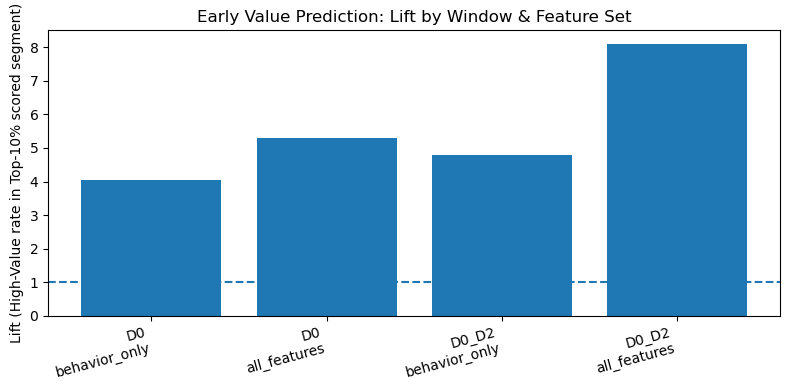

In [25]:
# ============================================================
# 2.3) Train interpretable trees + comparison summary (ROBUST)
# ============================================================

rows = []
reports = {}

for window_name, userw in window_tables.items():
    suffix = window_name.lower()

    # ---- FIX: Ensure required categorical cols exist ----
    # Some runs may lose platform/country depending on merge order in Cell 3. We fix here robustly.
    required_cols = ["platform", "country", "country_tier"]
    missing = [c for c in required_cols if c not in userw.columns]

    if missing:
        # Re-attach from outcomes
        userw = userw.merge(
            outcomes[["user_id", "platform", "country"]],
            on="user_id",
            how="left",
            suffixes=("", "_out")
        )

        # If country_tier missing, rebuild it quickly from available country + revenue_30d
        if "country_tier" not in userw.columns:
            if "revenue_30d" not in userw.columns:
                userw = userw.merge(outcomes[["user_id", "revenue_30d"]], on="user_id", how="left")

            tier_map = tier_countries_by_avg_revenue(userw, min_users=CFG2["MIN_USERS_PER_COUNTRY"])
            userw["country_tier"] = userw["country"].map(tier_map).fillna("Other_small")

        # If platform still missing, fallback
        if "platform" not in userw.columns:
            userw["platform"] = "unknown"

        # Update table back
        window_tables[window_name] = userw

    # ---- Train two models per window ----
    for feature_set in ["behavior_only", "all_features"]:
        rep = train_interpretable_tree(userw, suffix=suffix, feature_set=feature_set, cfg=CFG2)
        print_model_report(window_name=window_name, feature_set=feature_set, report=rep, top_rules=6, min_support=200)

        rows.append({
            "window": window_name,
            "feature_set": feature_set,
            "auc": rep["auc"],
            "pr_auc": rep["pr_auc"],
            "lift_top10": rep["lift_top10"],
        })
        reports[(window_name, feature_set)] = rep

comp = pd.DataFrame(rows).sort_values(["window", "feature_set"])
print("\n=== Comparison Summary ===")
print(comp.to_string(index=False))

# Plot lift comparison
plt.figure(figsize=(8, 4))
labels = [f"{r['window']}\n{r['feature_set']}" for r in rows]
lifts = [r["lift_top10"] for r in rows]
plt.bar(labels, lifts)
plt.axhline(1.0, linestyle="--")
plt.ylabel("Lift (High-Value rate in Top-10% scored segment)")
plt.title("Early Value Prediction: Lift by Window & Feature Set")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

----

## 3) Matchmaking & Skill–Engagement Loop (Win% × Match Volume → Retention & Value)

### Hypothesis (FPS-specific)
Early match outcomes strongly influence churn:
- **Low win-rate with high early volume** can indicate frustrating matchmaking (skill mismatch) → lower retention/value.
- **High win-rate with high volume** often correlates with strong engagement → higher value and payer likelihood.


### Approach

#### Build Early Signals (D0–D2):
1. **Win rate:** `wins / (wins + losses)`
2. **Match volume:** `wins + losses`
3. **Completion rate:** `match_end / match_start`
4. **Engagement intensity:** `duration/session`

#### Compute Outcomes (30-day Horizon):
- **Retention proxies:** D7/D14 retention.
- **Monetization:** 30D revenue (IAP + Ads), payer rate.
- **Engagement:** Active days.

#### Create a Grid:
- **Win% bucket × Match volume bucket grid**
- Compute lifts vs baseline.
- Visualize as heatmaps.


### Callouts
1. **Pain Points:** Low win% segments (especially high volume).
2. **Sweet Spots:** High win% segments with strong revenue/payer lift.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 3.1) Helpers
# ============================================================

CFG3 = {
    "HORIZON_DAYS": 30,
    "EARLY_WINDOW": (0, 2),          # D0-D2
    "RETENTION_DAYS": [7, 14],
    "MIN_USERS_CELL": 5000,

    "WIN_BINS": [0.0, 0.30, 0.50, 0.70, 1.0000001],
    "WIN_LABELS": ["<30%", "30–50%", "50–70%", ">=70%"],

    # Quantile edges for volume buckets (low/med/high/very-high)
    "MATCH_QUANTILES": [0.0, 0.50, 0.80, 0.95, 1.0],
}

def prep_horizon(game_data: pd.DataFrame, horizon_days: int) -> pd.DataFrame:
    """Parse dates, compute days_since_install, filter to 0..horizon-1, add total_revenue."""
    df = game_data.copy()
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
    df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
    df = df.dropna(subset=["event_date", "install_date"])

    df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")
    dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (horizon_days - 1))].copy()

    dfh["iap_revenue"] = pd.to_numeric(dfh["iap_revenue"], errors="coerce").fillna(0.0)
    dfh["ad_revenue"] = pd.to_numeric(dfh["ad_revenue"], errors="coerce").fillna(0.0)
    dfh["total_revenue"] = dfh["iap_revenue"] + dfh["ad_revenue"]

    for c in ["platform", "country"]:
        if c in dfh.columns:
            dfh[c] = dfh[c].astype("category")

    return dfh

def build_outcomes(dfh: pd.DataFrame, retention_days: list[int]) -> pd.DataFrame:
    """Outcomes per user within horizon: revenue_30d, payer flag, active days, retention proxies."""
    for d in retention_days:
        dfh[f"is_d{d}"] = (dfh["days_since_install"] == d).astype("int8")

    outcomes = dfh.groupby("user_id", as_index=False).agg(
        platform=("platform", "first"),
        country=("country", "first"),
        revenue_30d=("total_revenue", "sum"),
        iap_rev_30d=("iap_revenue", "sum"),
        ad_rev_30d=("ad_revenue", "sum"),
        active_days_30=("event_date", "nunique"),
        **{f"retained_d{d}": (f"is_d{d}", "max") for d in retention_days},
    )
    outcomes["payer_30d"] = (outcomes["iap_rev_30d"] > 0).astype("int8")
    return outcomes

def build_early_signals(dfh: pd.DataFrame, dmin: int, dmax: int) -> pd.DataFrame:
    """Early D0-D2 signals: win_rate, match volume, completion rate, engagement intensity."""
    early = dfh[dfh["days_since_install"].between(dmin, dmax)].copy()

    early_agg = early.groupby("user_id", as_index=False).agg(
        total_session_count_early=("total_session_count", "sum"),
        total_session_duration_early=("total_session_duration", "sum"),
        match_start_count_early=("match_start_count", "sum"),
        match_end_count_early=("match_end_count", "sum"),
        victory_count_early=("victory_count", "sum"),
        defeat_count_early=("defeat_count", "sum"),
        server_connection_error_early=("server_connection_error", "sum"),
    )

    wins = early_agg["victory_count_early"].astype("float64")
    losses = early_agg["defeat_count_early"].astype("float64")
    den = wins + losses

    early_agg["matches_played_early"] = den
    early_agg["win_rate_early"] = np.where(den > 0, wins / den, np.nan)

    starts = early_agg["match_start_count_early"].astype("float64")
    ends = early_agg["match_end_count_early"].astype("float64")
    early_agg["completion_rate_early"] = np.where(starts > 0, ends / starts, np.nan)

    sess = early_agg["total_session_count_early"].astype("float64")
    early_agg["duration_per_session_early"] = np.where(
        sess > 0, early_agg["total_session_duration_early"] / sess, 0.0
    )

    return early_agg

def make_match_volume_buckets(mp: pd.Series, quantiles: list[float]) -> tuple[np.ndarray, list[str]]:
    """Create stable quantile-based bin edges + readable labels; includes fallbacks."""
    mp = mp.fillna(0)
    edges = mp.quantile(quantiles).values
    edges = np.unique(edges)

    # Need at least 5 edges for 4 buckets
    if len(edges) < 5:
        edges = np.array([0, 1, 3, 8, mp.max() + 1], dtype=float)

    # Ensure last edge is > max
    edges[-1] = max(edges[-1], mp.max() + 1)

    labels = []
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        if i == len(edges) - 2:
            labels.append(f"{int(lo)}+ matches")
        else:
            labels.append(f"{int(lo)}–{max(int(hi)-1, int(lo))} matches")

    return edges, labels

def plot_heatmap(pivot_df: pd.DataFrame, title: str, fmt="{:.2f}"):
    """Simple matplotlib heatmap with annotations."""
    mat = pivot_df.values.astype(float)

    plt.figure(figsize=(10, 4))
    im = plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.xticks(range(len(pivot_df.columns)), pivot_df.columns, rotation=25, ha="right")
    plt.yticks(range(len(pivot_df.index)), pivot_df.index)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isfinite(mat[i, j]):
                plt.text(j, i, fmt.format(mat[i, j]), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


In [27]:
# ============================================================
# 3.2) Build user table and compute Win% × Match Volume grid
# ============================================================

dfh = prep_horizon(game_data, CFG3["HORIZON_DAYS"])
outcomes = build_outcomes(dfh, CFG3["RETENTION_DAYS"])

dmin, dmax = CFG3["EARLY_WINDOW"]
early = build_early_signals(dfh, dmin, dmax)

user = early.merge(outcomes, on="user_id", how="inner")

# Baselines
baseline = {
    "rev": user["revenue_30d"].mean(),
    "payer": user["payer_30d"].mean(),
}
if "retained_d7" in user.columns:
    baseline["d7"] = user["retained_d7"].mean()
if "retained_d14" in user.columns:
    baseline["d14"] = user["retained_d14"].mean()

print("=== Baselines (30D horizon) ===")
if "d7" in baseline:  print(f"D7 retention: {baseline['d7']:.4f}")
if "d14" in baseline: print(f"D14 retention: {baseline['d14']:.4f}")
print(f"Avg 30D revenue: {baseline['rev']:.4f}")
print(f"Payer rate (30D): {baseline['payer']:.4f}")

# Buckets
user["win_bucket"] = pd.cut(
    user["win_rate_early"],
    bins=CFG3["WIN_BINS"],
    labels=CFG3["WIN_LABELS"],
    right=False
)

mp = user["matches_played_early"].fillna(0)
edges, match_labels = make_match_volume_buckets(mp, CFG3["MATCH_QUANTILES"])

user["match_bucket"] = pd.cut(
    mp,
    bins=edges,
    labels=match_labels,
    right=False,
    include_lowest=True
)

# Keep users with decided matches and match bucket defined
user_heat = user.dropna(subset=["win_bucket", "match_bucket"]).copy()

# Groupby with observed=True prevents category expansion issues
agg = {
    "users": ("user_id", "nunique"),
    "avg_rev_30d": ("revenue_30d", "mean"),
    "payer_rate": ("payer_30d", "mean"),
    "avg_active_days": ("active_days_30", "mean"),
}
if "retained_d7" in user_heat.columns:
    agg["d7_retention"] = ("retained_d7", "mean")
if "retained_d14" in user_heat.columns:
    agg["d14_retention"] = ("retained_d14", "mean")

grid = (
    user_heat
    .groupby(["win_bucket", "match_bucket"], observed=True)
    .agg(**agg)
    .reset_index()
)

# Lifts
grid["rev_lift"] = grid["avg_rev_30d"] / baseline["rev"] if baseline["rev"] > 0 else np.nan
grid["payer_lift"] = grid["payer_rate"] / baseline["payer"] if baseline["payer"] > 0 else np.nan
if "d7_retention" in grid.columns and baseline.get("d7", 0) > 0:
    grid["d7_lift"] = grid["d7_retention"] / baseline["d7"]
if "d14_retention" in grid.columns and baseline.get("d14", 0) > 0:
    grid["d14_lift"] = grid["d14_retention"] / baseline["d14"]

# Top segments table (by revenue lift, min users)
MIN_USERS = CFG3["MIN_USERS_CELL"]
top = grid[grid["users"] >= MIN_USERS].sort_values("rev_lift", ascending=False).head(15)

print(f"\n=== Top 15 segments by revenue lift (min {MIN_USERS} users) ===")
print(top.to_string(index=False))


=== Baselines (30D horizon) ===
D7 retention: 0.0579
D14 retention: 0.0245
Avg 30D revenue: 0.2107
Payer rate (30D): 0.0101

=== Top 15 segments by revenue lift (min 5000 users) ===
win_bucket match_bucket  users  avg_rev_30d  payer_rate  avg_active_days  d7_retention  d14_retention  rev_lift  payer_lift  d7_lift  d14_lift
     >=70%  18+ matches  31853     3.022527    0.112737         6.456597      0.262456       0.135372 14.344070   11.172965 4.530870  5.533394
    50–70%  18+ matches  28074     1.857948    0.077509         7.116514      0.306191       0.151742  8.817303    7.681711 5.285885  6.202524
    50–70% 8–17 matches  32023     0.395498    0.017269         3.617587      0.112107       0.040627  1.876924    1.711459 1.935343  1.660651
     >=70% 8–17 matches 168274     0.312227    0.017489         3.432360      0.102422       0.040179  1.481742    1.733311 1.768153  1.642317
     >=70%  3–7 matches 287823     0.075261    0.006018         2.266914      0.051824       0.019717  

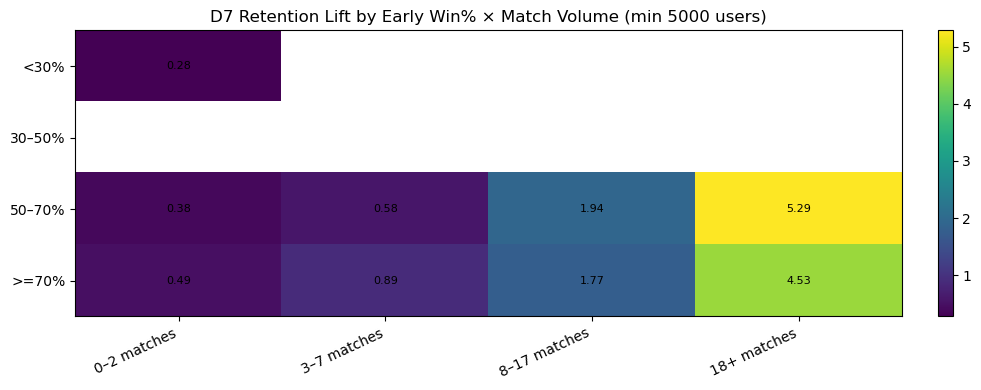

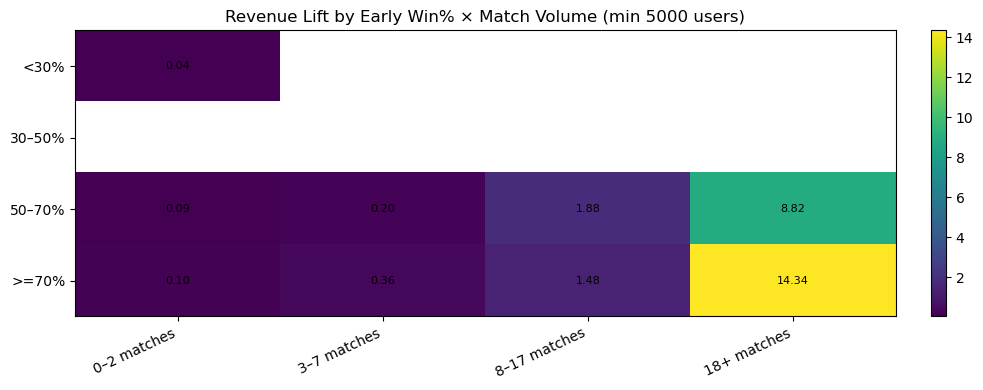

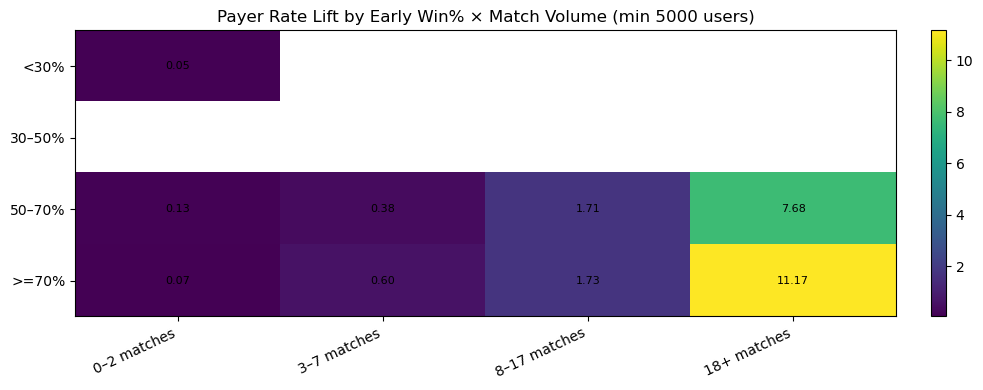


=== Potential Matchmaking Pain Points (low win-rate segments) ===
win_bucket match_bucket  users  avg_rev_30d  payer_rate  avg_active_days  d7_retention  d14_retention  rev_lift  payer_lift  d7_lift  d14_lift
      <30%  0–2 matches 135151      0.00789    0.000481         1.360486      0.016108       0.006408  0.037444    0.047665 0.278077  0.261916

=== High-Value Sweet Spots (high win-rate segments) ===
win_bucket match_bucket  users  avg_rev_30d  payer_rate  avg_active_days  d7_retention  d14_retention  rev_lift  payer_lift  d7_lift  d14_lift
     >=70%  18+ matches  31853     3.022527    0.112737         6.456597      0.262456       0.135372 14.344070   11.172965 4.530870  5.533394
    50–70%  18+ matches  28074     1.857948    0.077509         7.116514      0.306191       0.151742  8.817303    7.681711 5.285885  6.202524
    50–70% 8–17 matches  32023     0.395498    0.017269         3.617587      0.112107       0.040627  1.876924    1.711459 1.935343  1.660651
     >=70% 8–17 ma

In [28]:
# ============================================================
# 3.3) Heatmaps + Business summaries
# ============================================================

MIN_USERS = CFG3["MIN_USERS_CELL"]

def pivot_metric(metric: str) -> pd.DataFrame:
    p = grid.pivot(index="win_bucket", columns="match_bucket", values=metric)
    counts = grid.pivot(index="win_bucket", columns="match_bucket", values="users")
    return p.where(counts >= MIN_USERS)

# Heatmaps
if "d7_lift" in grid.columns:
    plot_heatmap(pivot_metric("d7_lift"), f"D7 Retention Lift by Early Win% × Match Volume (min {MIN_USERS} users)")
plot_heatmap(pivot_metric("rev_lift"), f"Revenue Lift by Early Win% × Match Volume (min {MIN_USERS} users)")
plot_heatmap(pivot_metric("payer_lift"), f"Payer Rate Lift by Early Win% × Match Volume (min {MIN_USERS} users)")

# Callouts
pain = grid[
    (grid["users"] >= MIN_USERS) &
    (grid["win_bucket"] == "<30%")
].copy()

# Prefer retention if available, else revenue lift
sort_col = "d7_retention" if "d7_retention" in pain.columns else "rev_lift"
pain = pain.sort_values(sort_col, ascending=True).head(5)

print("\n=== Potential Matchmaking Pain Points (low win-rate segments) ===")
print(pain.to_string(index=False))

sweet = grid[
    (grid["users"] >= MIN_USERS) &
    (grid["win_bucket"].isin([">=70%", "50–70%"]))
].sort_values("rev_lift", ascending=False).head(5)

print("\n=== High-Value Sweet Spots (high win-rate segments) ===")
print(sweet.to_string(index=False))


----

## 4) Monetization Ladder & Revenue Mix (Whales / Dolphins / Minnows)

### Why This Matters (F2P Shooter)
- **F2P economies are highly skewed:** A small fraction of users (“whales”) typically drives most revenue.
- **Strategic importance:** Early product strategy depends on whether the game is IAP-driven, ad-driven, or hybrid. This often varies by platform (iOS vs Android) and market (country tier).


### What We Do

#### Compute 30-Day User-Level Outcomes:
1. **Revenue metrics:** IAP, Ads, total revenue.
2. **Flags:** Payer flag, ad-monetizer flag.
3. **Engagement:** Active days.

#### Define Tiers (Non / Minnow / Dolphin / Whale):
- **IAP revenue:** Among payers.
- **Ad revenue:** Among ad-monetizers.
- **Total revenue:** Among monetizers.

#### Define Monetization Mix Archetypes:
1. **Non-monetizer**
2. **Ad-dominant**
3. **IAP-dominant**
4. **Hybrid**

#### Segment by Platform and Country Tier:
1. **Who monetizes (and how):** Revenue share by archetype.
2. **Revenue concentration:** Pareto curve (e.g., top 1% users drive X% of revenue).
3. **Whale driver split:** IAP-driven vs Ad-driven whales.


### Outputs
1. **Revenue tiers:** Minnows, Dolphins, Whales.
2. **Monetization mix:** Archetypes by platform and country tier.
3. **Revenue concentration:** Pareto analysis.
4. **Whale composition:** IAP-driven vs Ad-driven.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 4.1) Helpers
# ============================================================

CFG4 = {
    "HORIZON_DAYS": 30,
    "MIN_USERS_COUNTRY": 5000,
    "TOP_COUNTRIES_BY_USERS": 12,
    "PARETO_TOP_K": 2000, # This worked well for our data size

    # Tier cutoffs (quantiles among >0 users)
    "IAP_WHALE_Q": 0.99,
    "IAP_DOLPHIN_Q": 0.95,

    "AD_WHALE_Q": 0.99,
    "AD_DOLPHIN_Q": 0.95,

    "TOTAL_WHALE_Q": 0.99,
    "TOTAL_DOLPHIN_Q": 0.95,

    # Mix thresholds
    "IAP_DOM_MAX_AD_SHARE": 0.20,
    "AD_DOM_MIN_AD_SHARE": 0.80,
}

def prep_horizon_user_table(game_data: pd.DataFrame, horizon_days: int) -> pd.DataFrame:
    """Parse dates, filter to 0..horizon-1, aggregate to user-level 30D metrics."""
    df = game_data.copy()

    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
    df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
    df = df.dropna(subset=["event_date", "install_date"])

    df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")
    dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (horizon_days - 1))].copy()

    dfh["iap_revenue"] = pd.to_numeric(dfh["iap_revenue"], errors="coerce").fillna(0.0)
    dfh["ad_revenue"] = pd.to_numeric(dfh["ad_revenue"], errors="coerce").fillna(0.0)
    dfh["total_revenue"] = dfh["iap_revenue"] + dfh["ad_revenue"]

    # Fill missing metadata
    if "country" in dfh.columns:
        dfh["country"] = dfh["country"].fillna("Unknown")
    if "platform" in dfh.columns:
        dfh["platform"] = dfh["platform"].fillna("unknown")

    # User outcomes + metadata
    user = dfh.groupby("user_id", as_index=False).agg(
        platform=("platform", "first"),
        country=("country", "first"),
        install_date=("install_date", "first"),
        iap_30d=("iap_revenue", "sum"),
        ad_30d=("ad_revenue", "sum"),
        total_30d=("total_revenue", "sum"),
        active_days_30=("event_date", "nunique"),
    )

    user["payer_30d"] = (user["iap_30d"] > 0).astype("int8")
    user["ad_monetizer_30d"] = (user["ad_30d"] > 0).astype("int8")
    user["monetizer_30d"] = (user["total_30d"] > 0).astype("int8")
    user["ad_share_30d"] = np.where(user["total_30d"] > 0, user["ad_30d"] / user["total_30d"], 0.0)

    user["platform"] = user["platform"].astype("category")
    user["country"] = user["country"].astype("category")

    return user

def assign_tiers(values: pd.Series, whale_q: float, dolphin_q: float):
    """
    Tiering on quantiles among users with values > 0.
    Whale: >= q(whale), Dolphin: [q(dolphin), q(whale)), Minnow: (0, q(dolphin)), Non: == 0
    """
    v = values.fillna(0.0)
    tiers = pd.Series("Non", index=v.index)

    mask = v > 0
    if mask.sum() == 0:
        return tiers, (np.nan, np.nan)

    q_whale = float(v[mask].quantile(whale_q))
    q_dolph = float(v[mask].quantile(dolphin_q))

    tiers.loc[mask & (v >= q_whale)] = "Whale"
    tiers.loc[mask & (v >= q_dolph) & (v < q_whale)] = "Dolphin"
    tiers.loc[mask & (v < q_dolph)] = "Minnow"
    return tiers, (q_dolph, q_whale)

def classify_mix(user: pd.DataFrame, iap_dom_max_ad_share: float, ad_dom_min_ad_share: float) -> pd.Series:
    """Assign mix archetypes based on ad_share and payer/ad flags."""
    def fn(row):
        if row["total_30d"] <= 0:
            return "Non-monetizer"
        if row["payer_30d"] == 1 and row["ad_share_30d"] < iap_dom_max_ad_share:
            return "IAP-dominant"
        if row["ad_monetizer_30d"] == 1 and row["ad_share_30d"] > ad_dom_min_ad_share:
            return "Ad-dominant"
        return "Hybrid"
    return user.apply(fn, axis=1)

def add_country_tiers(user: pd.DataFrame, min_users: int) -> pd.DataFrame:
    """Self-contained country tiering by avg_total (no external GDP)."""
    cs = user.groupby("country", as_index=False).agg(
        users=("user_id", "nunique"),
        avg_total=("total_30d", "mean"),
    )
    eligible = cs[cs["users"] >= min_users].copy()
    if eligible.empty:
        user["country_tier"] = "Other_small"
        return user

    q1, q2 = eligible["avg_total"].quantile([0.33, 0.66]).values

    def tier(x):
        if x <= q1: return "Tier3_low"
        if x <= q2: return "Tier2_mid"
        return "Tier1_high"

    eligible["country_tier"] = eligible["avg_total"].apply(tier)
    tier_map = dict(zip(eligible["country"], eligible["country_tier"]))
    user["country_tier"] = user["country"].map(tier_map).fillna("Other_small")
    user["country_tier"] = user["country_tier"].astype("category")
    return user

def summarize(user: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """Group summary with user share + revenue share (safe + readable)."""
    total_users = user["user_id"].nunique()
    total_rev = user["total_30d"].sum()

    out = user.groupby(group_cols, observed=True).agg(
        users=("user_id", "nunique"),
        total_rev=("total_30d", "sum"),
        avg_rev=("total_30d", "mean"),
        avg_iap=("iap_30d", "mean"),
        avg_ad=("ad_30d", "mean"),
        payer_rate=("payer_30d", "mean"),
        ad_monet_rate=("ad_monetizer_30d", "mean"),
        avg_ad_share=("ad_share_30d", "mean"),
        avg_active_days=("active_days_30", "mean"),
    ).reset_index()

    out["share_users"] = out["users"] / total_users if total_users > 0 else np.nan
    out["share_rev"] = out["total_rev"] / total_rev if total_rev > 0 else np.nan
    return out

def plot_pareto(user: pd.DataFrame, top_k: int):
    """Revenue concentration curve (Pareto-style)."""
    total_rev = user["total_30d"].sum()
    if total_rev <= 0:
        print("No revenue to plot Pareto.")
        return

    sorted_rev = user.sort_values("total_30d", ascending=False).reset_index(drop=True)
    sorted_rev["cum_rev_share"] = sorted_rev["total_30d"].cumsum() / total_rev
    sorted_rev["cum_user_share"] = (np.arange(len(sorted_rev)) + 1) / len(sorted_rev)

    # Print key Pareto points
    for pct in [0.01, 0.05, 0.10]:
        k = max(int(len(sorted_rev) * pct), 1)
        share = float(sorted_rev.loc[k - 1, "cum_rev_share"])
        print(f"Pareto: Top {pct:.0%} users generate {share:.1%} of total revenue (30D).")

    k = min(top_k, len(sorted_rev))
    plt.figure(figsize=(7, 4))
    plt.plot(sorted_rev.loc[:k-1, "cum_user_share"], sorted_rev.loc[:k-1, "cum_rev_share"])
    plt.axline((0, 0), slope=1, linestyle="--")
    plt.xlabel("Cumulative user share")
    plt.ylabel("Cumulative revenue share")
    plt.title(f"Revenue Concentration Curve (Top {k} users shown)")
    plt.tight_layout()
    plt.show()

def plot_rev_share_by_archetype(mix_sum: pd.DataFrame):
    """Simple revenue share bar plot (story-friendly)."""
    x = mix_sum["mix_archetype"].astype(str).tolist()
    y = mix_sum["share_rev"].astype(float).tolist()

    plt.figure(figsize=(7, 4))
    plt.bar(x, y)
    plt.ylabel("Share of total revenue")
    plt.title("Revenue Share by Monetization Mix Archetype (30D)")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


In [30]:
# ============================================================
# 4.2) Build user table, tiers, archetypes, country tiers
# ============================================================

user = prep_horizon_user_table(game_data, CFG4["HORIZON_DAYS"])

# Baselines
base = {
    "avg_total": user["total_30d"].mean(),
    "avg_iap": user["iap_30d"].mean(),
    "avg_ad": user["ad_30d"].mean(),
    "payer_rate": user["payer_30d"].mean(),
    "ad_monet_rate": user["ad_monetizer_30d"].mean(),
}
print("=== Baselines (30D horizon) ===")
print(f"Users: {len(user):,}")
print(f"Avg total rev/user: {base['avg_total']:.4f} (IAP {base['avg_iap']:.4f} + Ad {base['avg_ad']:.4f})")
print(f"Payer rate: {base['payer_rate']:.4f} | Ad-monetizer rate: {base['ad_monet_rate']:.4f}")

# Tiers (fixed: separate dolphin_q for Ad tiers)
user["iap_tier"], (iap_dolph_thr, iap_whale_thr) = assign_tiers(
    user["iap_30d"], whale_q=CFG4["IAP_WHALE_Q"], dolphin_q=CFG4["IAP_DOLPHIN_Q"]
)
user["ad_tier"], (ad_dolph_thr, ad_whale_thr) = assign_tiers(
    user["ad_30d"], whale_q=CFG4["AD_WHALE_Q"], dolphin_q=CFG4["AD_DOLPHIN_Q"]
)
user["total_tier"], (tot_dolph_thr, tot_whale_thr) = assign_tiers(
    user["total_30d"], whale_q=CFG4["TOTAL_WHALE_Q"], dolphin_q=CFG4["TOTAL_DOLPHIN_Q"]
)

print("\n=== Tier thresholds (among >0 users) ===")
print(f"IAP: Dolphin>= {iap_dolph_thr:.4f}, Whale>= {iap_whale_thr:.4f}")
print(f"Ad : Dolphin>= {ad_dolph_thr:.4f}, Whale>= {ad_whale_thr:.4f}")
print(f"Tot: Dolphin>= {tot_dolph_thr:.4f}, Whale>= {tot_whale_thr:.4f}")

# Mix archetypes
user["mix_archetype"] = classify_mix(
    user,
    iap_dom_max_ad_share=CFG4["IAP_DOM_MAX_AD_SHARE"],
    ad_dom_min_ad_share=CFG4["AD_DOM_MIN_AD_SHARE"],
)
user["mix_archetype"] = user["mix_archetype"].astype("category")

# Country tiers + top countries
user = add_country_tiers(user, min_users=CFG4["MIN_USERS_COUNTRY"])

country_stats = user.groupby("country", as_index=False).agg(
    users=("user_id", "nunique"),
    avg_total=("total_30d", "mean"),
).sort_values("users", ascending=False)

top_countries = country_stats.head(CFG4["TOP_COUNTRIES_BY_USERS"])["country"].tolist()
user["is_top_country"] = user["country"].isin(top_countries).astype("int8")

# Core tables
print("\n=== Monetization Mix Archetypes (overall) ===")
mix_sum = summarize(user, ["mix_archetype"]).sort_values("total_rev", ascending=False)
print(mix_sum.to_string(index=False))

print("\n=== Total Tier (overall) ===")
tot_sum = summarize(user, ["total_tier"]).sort_values("total_rev", ascending=False)
print(tot_sum.to_string(index=False))

print("\n=== IAP Tier (overall) ===")
iap_sum = summarize(user, ["iap_tier"]).sort_values("total_rev", ascending=False)
print(iap_sum.to_string(index=False))

print("\n=== Platform × Mix Archetype ===")
plat_mix = summarize(user, ["platform", "mix_archetype"]).sort_values(["platform", "total_rev"], ascending=[True, False])
print(plat_mix.to_string(index=False))

print("\n=== Country Tier × Mix Archetype ===")
ct_mix = summarize(user, ["country_tier", "mix_archetype"]).sort_values(["country_tier", "total_rev"], ascending=[True, False])
print(ct_mix.to_string(index=False))

print(f"\n=== Top {CFG4['TOP_COUNTRIES_BY_USERS']} Countries by Users: Mix Archetypes (compact) ===")
top_country_mix = (
    user[user["is_top_country"] == 1]
    .groupby(["country", "mix_archetype"], observed=True)
    .agg(
        users=("user_id", "nunique"),
        avg_rev=("total_30d", "mean"),
        payer_rate=("payer_30d", "mean"),
        avg_ad_share=("ad_share_30d", "mean"),
    )
    .reset_index()
    .sort_values(["country", "users"], ascending=[True, False])
)
print(top_country_mix.to_string(index=False))


=== Baselines (30D horizon) ===
Users: 1,446,296
Avg total rev/user: 0.2510 (IAP 0.1960 + Ad 0.0549)
Payer rate: 0.0113 | Ad-monetizer rate: 0.4097

=== Tier thresholds (among >0 users) ===
IAP: Dolphin>= 63.2203, Whale>= 256.0439
Ad : Dolphin>= 0.5233, Whale>= 1.8045
Tot: Dolphin>= 0.7363, Whale>= 6.3862


C:\Users\kagan_ntaijui\AppData\Local\Temp\ipykernel_708\386504918.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cs = user.groupby("country", as_index=False).agg(
C:\Users\kagan_ntaijui\AppData\Local\Temp\ipykernel_708\3327696733.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_stats = user.groupby("country", as_index=False).agg(



=== Monetization Mix Archetypes (overall) ===
mix_archetype  users     total_rev   avg_rev   avg_iap   avg_ad  payer_rate  ad_monet_rate  avg_ad_share  avg_active_days  share_users  share_rev
 IAP-dominant  11184 278059.214465 24.862233 24.469080 0.393154    1.000000       0.742489      0.047847         8.340576     0.007733   0.766017
  Ad-dominant 579513  68416.292957  0.118058  0.000374 0.117685    0.000544       1.000000      0.999928         3.476302     0.400688   0.188478
       Hybrid   4798  16518.102158  3.442706  2.011679 1.431027    1.000000       1.000000      0.430203         9.957691     0.003317   0.045505
Non-monetizer 850801      0.000000  0.000000  0.000000 0.000000    0.000000       0.000000      0.000000         1.491426     0.588262   0.000000

=== Total Tier (overall) ===
total_tier  users     total_rev   avg_rev   avg_iap   avg_ad  payer_rate  ad_monet_rate  avg_ad_share  avg_active_days  share_users  share_rev
     Whale   5955 278490.961240 46.765904 44.76756


=== Revenue Concentration (Pareto) ===
Pareto: Top 1% users generate 84.3% of total revenue (30D).
Pareto: Top 5% users generate 93.9% of total revenue (30D).
Pareto: Top 10% users generate 96.9% of total revenue (30D).


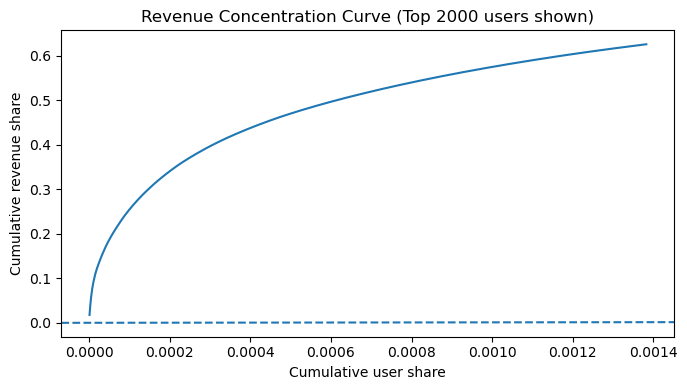

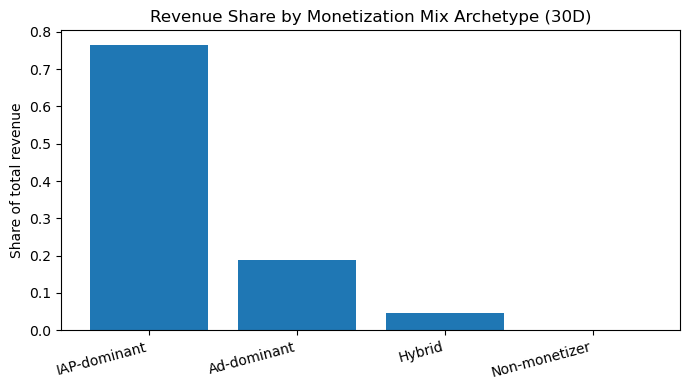


=== Total Whales: Driver × Platform × Country Tier (top rows) ===
whale_driver platform country_tier  users  avg_total   avg_iap    avg_ad  avg_ad_share  avg_active_days
  IAP-driven      ios   Tier1_high   1671  58.198117 57.194422  1.003695      0.052483        10.667265
  IAP-driven  android   Tier1_high   1179  61.259634 59.634430  1.625204      0.064192        11.335878
  IAP-driven  android    Tier2_mid    734  35.440777 34.476570  0.964208      0.060659        13.355586
  IAP-driven      ios    Tier2_mid    622  47.171831 46.521891  0.649940      0.041919        13.421222
  IAP-driven      ios  Other_small    310  44.822250 44.232781  0.589468      0.036417        10.464516
   Ad-driven  android   Tier1_high    292  12.707117  1.430564 11.276553      0.887834        12.301370
  IAP-driven  android    Tier3_low    277  22.455316 21.861407  0.593910      0.047997        12.992780
  IAP-driven  android  Other_small    269  63.511071 62.351244  1.159827      0.060432        12.2862

In [31]:
# ============================================================
# 4.3 — Visuals + Whale driver breakdown
# ============================================================

# Visual 1: Pareto curve
print("\n=== Revenue Concentration (Pareto) ===")
plot_pareto(user, top_k=CFG4["PARETO_TOP_K"])

# Visual 2: Revenue share by archetype (easy slide)
plot_rev_share_by_archetype(mix_sum)

# Whale driver split (Total whales)
whales_total = user[user["total_tier"] == "Whale"].copy()
if len(whales_total) == 0:
    print("\nNo total whales found (unexpected if monetization exists).")
else:
    whales_total["whale_driver"] = np.where(
        whales_total["iap_30d"] >= whales_total["ad_30d"],
        "IAP-driven",
        "Ad-driven"
    )

    whale_comp = whales_total.groupby(["whale_driver", "platform", "country_tier"], observed=True).agg(
        users=("user_id", "nunique"),
        avg_total=("total_30d", "mean"),
        avg_iap=("iap_30d", "mean"),
        avg_ad=("ad_30d", "mean"),
        avg_ad_share=("ad_share_30d", "mean"),
        avg_active_days=("active_days_30", "mean"),
    ).reset_index().sort_values("users", ascending=False)

    print("\n=== Total Whales: Driver × Platform × Country Tier (top rows) ===")
    print(whale_comp.head(25).to_string(index=False))
